In [8]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [12]:
#قراءة البيانات 
import pandas as pd

data = pd.read_csv(r"C:\Users\Elite\Arabic_Fake_News_detection\data\fake_news_data.csv")

data.head()

,Label,Topic,Article_content
0,real,politics,القدس المحتلة- لن يتمكن المقدسي سامي درويش في ...
1,real,politics,طهران- منذ الهجوم الإسرائيلي على القنصلية الإي...
2,real,politics,غادر المحامي الفلسطيني راجي صوراني قطاع غزة رف...
3,real,politics,نابلس- لليوم الثاني على التوالي، تتعرض قرية دو...
4,real,politics,بريتوريا- تقدمت اللجنة المستقلة للانتخابات في ...


In [13]:
# كود عرض عدد البيانات 
data.shape

(46097, 3)

In [14]:
# مرحلة تنظيف البيانات 
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

data['label_encoded'] = encoder.fit_transform(data['Label'])

data[['Label','label_encoded']].head()

,Label,label_encoded
0,real,1
1,real,1
2,real,1
3,real,1
4,real,1


In [15]:
# كود عرض عمود البيانات 
data.columns

Index(['Label', 'Topic', 'Article_content', 'label_encoded'], dtype='object')

In [16]:
# كود التنظيف الذي ينشى العمود
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r'[^\w\s]', '', text)   # إزالة الرموز
    text = re.sub(r'\d+', '', text)       # إزالة الأرقام
    text = text.lower()                   # تحويل لحروف صغيرة
    text = text.strip()
    return text

data['clean_text'] = data['Article_content'].apply(clean_text)

data[['Article_content','clean_text']].head()

,Article_content,clean_text
0,القدس المحتلة- لن يتمكن المقدسي سامي درويش في ...,القدس المحتلة لن يتمكن المقدسي سامي درويش في م...
1,طهران- منذ الهجوم الإسرائيلي على القنصلية الإي...,طهران منذ الهجوم الإسرائيلي على القنصلية الإير...
2,غادر المحامي الفلسطيني راجي صوراني قطاع غزة رف...,غادر المحامي الفلسطيني راجي صوراني قطاع غزة رف...
3,نابلس- لليوم الثاني على التوالي، تتعرض قرية دو...,نابلس لليوم الثاني على التوالي تتعرض قرية دوما...
4,بريتوريا- تقدمت اللجنة المستقلة للانتخابات في ...,بريتوريا تقدمت اللجنة المستقلة للانتخابات في ج...


In [22]:
#  كود المرحلة التي بعد التنظيف مباشرة
#Tokenization + تحويل النص إلى أرقام + Padding + تقسيم البيانات

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# 1) تحويل النصوص إلى أرقام
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(data['clean_text'])

sequences = tokenizer.texts_to_sequences(data['clean_text'])

# 2) توحيد طول النصوص
X = pad_sequences(sequences, maxlen=100, padding='post', truncating='post')

# 3) تجهيز التصنيفات
y = data['label_encoded']

# 4) تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5) عرض الأشكال للتأكد
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X shape: (46097, 100)
y shape: (46097,)
X_train shape: (36877, 100)
X_test shape: (9220, 100)
y_train shape: (36877,)
y_test shape: (9220,)


In [18]:
# للتأكد أن التحويل تم بشكل صحيح، شغّل بعدها هذا
print(data['clean_text'].iloc[0])
print(sequences[0])
print(X[0])

القدس المحتلة لن يتمكن المقدسي سامي درويش في موسم الزيتون المقبل من قطف ثمار أشجاره التي ألفت أغصانها كفيه منذ عقود لأن المحكمة الإسرائيلية العليا أصدرت قرارا نهائيا بمصادرة أرضه الواقعة في قلب مستوطنة جيلو جنوب القدس وانتهى بذلك المسار القانوني والمعركة القضائية التي يخوضها هذا الرجل منذ عام  في ذلك العام أعلنت الحكومة الإسرائيلية مصادرة  ألف دونم الدونم يساوي ألف متر مربع بشكل سريع وعشوائي لصالح إقامة مستوطنات محاذية لمدينة القدس ومن بين الأراضي قطعة الأرض التي تتبع لعائلة درويش المهجرة من قرية المالحة عام  والتي تقدر مساحتها بـ دونما وبسبب وجود  منازل للعائلة في منتصف الأرض استثنت الحكومة الإسرائيلية ما مساحته  دونما و مترا مربعا من المصادرة ومنحت العائلة أوراقا تثبت حقها في ذلك عام  من دائرة أراضي إسرائيل في حديثه للجزيرة نت قال صاحب الأرض سامي درويش إن الحال بقيت على ما هو عليه منذ منتصف سبعينيات القرن الماضي حتى عام  عندما ادعت الدائرة ذاتها وبلدية الاحتلال في القدس أن الأوراق الثبوتية التي تملكها العائلة ينقصها توقيع وزير المالية الإسرائيلي وهو الوحيد المخول بتحرير أرض من المصاد

In [19]:
from sklearn.model_selection import train_test_split

y = data['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (36877, 100)
X_test shape: (9220, 100)
y_train shape: (36877,)
y_test shape: (9220,)


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=128, input_length=100))
model.add(LSTM(128))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

C:\Users\Elite\anaconda3\envs\myenv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 133s 115ms/step - accuracy: 0.9660 - loss: 0.1443 - val_accuracy: 0.9715 - val_loss: 0.1317
Epoch 2/5
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 149s 129ms/step - accuracy: 0.9717 - loss: 0.1215 - val_accuracy: 0.9867 - val_loss: 0.0387
Epoch 3/5
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 143s 124ms/step - accuracy: 0.9904 - loss: 0.0332 - val_accuracy: 0.9958 - val_loss: 0.0158
Epoch 4/5
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 146s 127ms/step - accuracy: 0.9986 - loss: 0.0063 - val_accuracy: 0.9958 - val_loss: 0.0188
Epoch 5/5
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 121s 105ms/step - accuracy: 0.9969 - loss: 0.0106 - val_accuracy: 0.9967 - val_loss: 0.0159


In [24]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

289/289 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.9967 - loss: 0.0159
Test Accuracy: 0.9967461824417114


In [25]:
sample_text = "أعلنت الحكومة عن مشروع اقتصادي جديد لدعم الشباب"

sample_text = clean_text(sample_text)
sample_seq = tokenizer.texts_to_sequences([sample_text])
sample_pad = pad_sequences(sample_seq, maxlen=100)

prediction = model.predict(sample_pad)

if prediction[0][0] > 0.5:
    print("Fake News")
else:
    print("Real News")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
Real News


In [21]:
sample_text = "امريكا تقتل الشعب الايراني وتنهب ثراوته"

sample_text = clean_text(sample_text)
sample_seq = tokenizer.texts_to_sequences([sample_text])
sample_pad = pad_sequences(sample_seq, maxlen=100)

prediction = model.predict(sample_pad)

if prediction[0][0] > 0.5:
    print("Fake News")
else:
    print("Real News")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
Real News


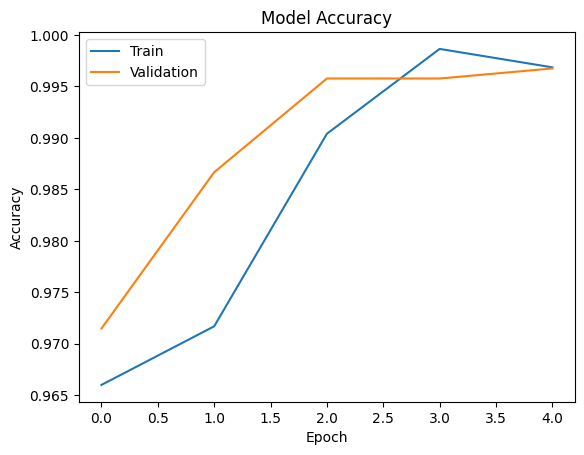

In [26]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

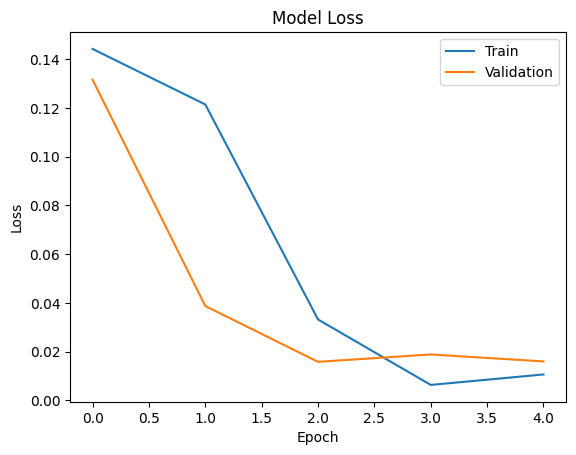

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

In [28]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

289/289 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step


In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8443
           1       0.98      0.98      0.98       777

    accuracy                           1.00      9220
   macro avg       0.99      0.99      0.99      9220
weighted avg       1.00      1.00      1.00      9220



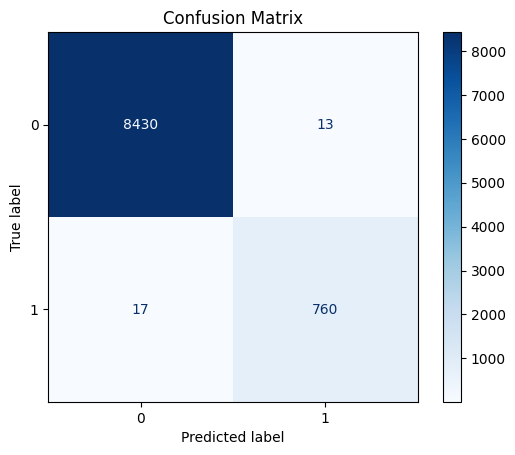

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

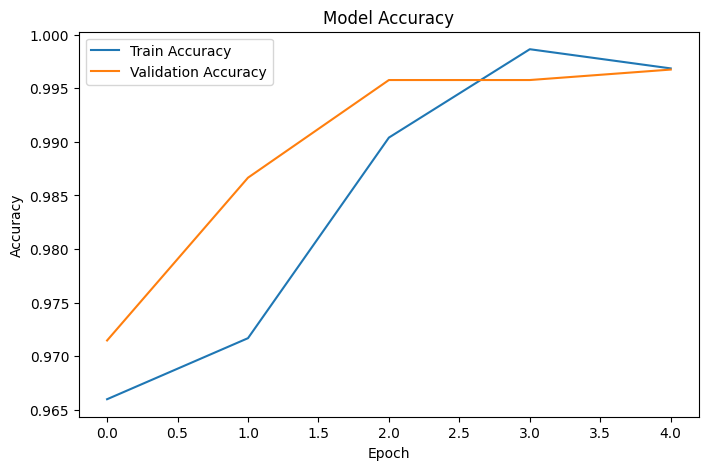

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

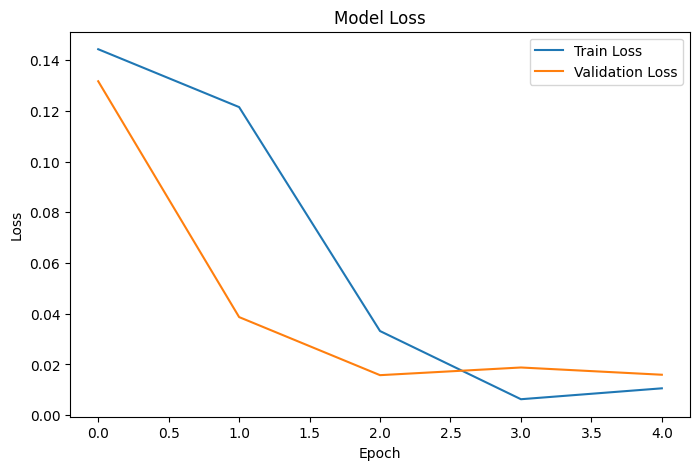

In [32]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [33]:
model.save("arabic_fake_news_lstm.h5")
print("Model saved successfully")

Model saved successfully


In [34]:
sample_text = "أعلنت الحكومة عن مشروع اقتصادي جديد لدعم الشباب"

sample_text_clean = clean_text(sample_text)
sample_seq = tokenizer.texts_to_sequences([sample_text_clean])
sample_pad = pad_sequences(sample_seq, maxlen=100, padding='post', truncating='post')

prediction = model.predict(sample_pad)

print("Prediction value:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Fake News")
else:
    print("Real News")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Prediction value: 0.5518211
Fake News


In [35]:
print(encoder.classes_)

['fake' 'real']


In [36]:
sample_text = "أعلنت مجموعة من العلماء عن اكتشاف علاج نهائي لجميع أنواع السرطان يمكنه شفاء المرض خلال 48 ساعة فقط، وسيتم طرحه في الأسواق العالمية خلال الشهر القادم دون الحاجة لأي تجارب طبية إضافية."

sample_text_clean = clean_text(sample_text)
sample_seq = tokenizer.texts_to_sequences([sample_text_clean])
sample_pad = pad_sequences(sample_seq, maxlen=100)

prediction = model.predict(sample_pad)

pred_label = (prediction > 0.5).astype("int32")[0][0]
print("Prediction:", encoder.inverse_transform([pred_label])[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Prediction: fake


In [37]:
tests = [
"اكتشف علماء علاج نهائي للسرطان خلال 48 ساعة",
"أعلنت الحكومة عن مشروع اقتصادي جديد",
"تم اختراع دواء يجعل الإنسان لا يحتاج للنوم",
"افتتاح مركز جديد لأبحاث الذكاء الاصطناعي"
]

for text in tests:
    
    text_clean = clean_text(text)
    seq = tokenizer.texts_to_sequences([text_clean])
    pad = pad_sequences(seq, maxlen=100)
    
    pred = model.predict(pad)
    
    label = (pred > 0.5).astype("int32")[0][0]
    
    print(text)
    print("Prediction:", encoder.inverse_transform([label])[0])
    print("---------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
اكتشف علماء علاج نهائي للسرطان خلال 48 ساعة
Prediction: fake
---------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
أعلنت الحكومة عن مشروع اقتصادي جديد
Prediction: fake
---------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
تم اختراع دواء يجعل الإنسان لا يحتاج للنوم
Prediction: fake
---------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
افتتاح مركز جديد لأبحاث الذكاء الاصطناعي
Prediction: fake
---------------


In [38]:
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

# أخبار حقيقية
real_news = [
    "أعلنت وزارة التعليم عن إطلاق برنامج جديد لدعم الطلاب الموهوبين في مجالات التكنولوجيا.",
    "افتتحت الحكومة مركزًا جديدًا للأبحاث العلمية لدعم الابتكار.",
    "ارتفعت أسعار النفط في الأسواق العالمية بعد تقارير عن انخفاض الإنتاج.",
    "أطلقت شركة تقنية تحديثًا جديدًا لنظام التشغيل لتحسين الأمان.",
    "افتتحت مدينة جديدة تعتمد على الطاقة الشمسية لتوليد الكهرباء."
]

# أخبار مزيفة
fake_news = [
    "اكتشف علماء علاجًا نهائيًا لجميع الأمراض خلال يوم واحد.",
    "أعلنت شركة تقنية أنها طورت هاتفًا يعمل عشر سنوات دون شحن.",
    "اختراع جهاز يسمح بقراءة أفكار الآخرين.",
    "اكتشاف مدينة ذهبية كاملة تحت الصحراء.",
    "دواء جديد يجعل الإنسان لا يحتاج للنوم."
]

# جمع الأخبار مع التصنيف الحقيقي
texts = real_news + fake_news
true_labels = ["real"] * len(real_news) + ["fake"] * len(fake_news)

# إنشاء DataFrame
test_df = pd.DataFrame({
    "text": texts,
    "true_label": true_labels
})

# تنظيف النصوص
test_df["clean_text"] = test_df["text"].apply(clean_text)

# تحويل النصوص إلى أرقام
seq = tokenizer.texts_to_sequences(test_df["clean_text"])
pad = pad_sequences(seq, maxlen=100, padding='post', truncating='post')

# التنبؤ
pred_prob = model.predict(pad)
pred_binary = (pred_prob > 0.5).astype("int32").flatten()

# تحويل الأرقام إلى أسماء الفئات
pred_labels = encoder.inverse_transform(pred_binary)

# إضافة النتائج
test_df["predicted_label"] = pred_labels
test_df["prediction_value"] = pred_prob.flatten()

# عرض النتائج
print(test_df[["text", "true_label", "predicted_label", "prediction_value"]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
                                                text true_label  \
0  أعلنت وزارة التعليم عن إطلاق برنامج جديد لدعم ...       real   
1  افتتحت الحكومة مركزًا جديدًا للأبحاث العلمية ل...       real   
2  ارتفعت أسعار النفط في الأسواق العالمية بعد تقا...       real   
3  أطلقت شركة تقنية تحديثًا جديدًا لنظام التشغيل ...       real   
4  افتتحت مدينة جديدة تعتمد على الطاقة الشمسية لت...       real   
5  اكتشف علماء علاجًا نهائيًا لجميع الأمراض خلال ...       fake   
6  أعلنت شركة تقنية أنها طورت هاتفًا يعمل عشر سنو...       fake   
7             اختراع جهاز يسمح بقراءة أفكار الآخرين.       fake   
8              اكتشاف مدينة ذهبية كاملة تحت الصحراء.       fake   
9             دواء جديد يجعل الإنسان لا يحتاج للنوم.       fake   

  predicted_label  prediction_value  
0            fake          0.004068  
1            fake          0.007046  
2            real          0.998463  
3            fake          0.000052  
4            fake          0.0000

In [40]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(test_df["true_label"], test_df["predicted_label"])
print("Accuracy on test news:", acc)

Accuracy on test news: 0.5


In [42]:
model.save("model/fake_news_model.h5")

In [43]:
model = Sequential()

In [46]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.save("model/fake_news_model.h5")

import pickle

with open("model/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("model/label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)